# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

# Titanic Character Profiles: Most Likely to Survive vs Least Likely to Survive

In this lab, I used the Titanic passenger dataset to create two character profiles for a reboot of the Titanic movie:
1. A character most likely to survive the sinking
2. A character least likely to survive the sinking

I based each profile on patterns in the dataset, using features such as age, fare, sex, passenger class, travel companions, and port of departure. I also used visualizations to support each part of the profiles and identified real passengers in the dataset who matched each profile.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic_passengers.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    

## Creating Age and Fare Categories

To make the profiles easier to build, I grouped passengers into age and fare categories.

### Age Groups
I used life-stage categories:
- Child: under 12
- Teen: 12 to 17
- Adult: 18 to 59
- Senior: 60 and older

### Fare Groups
I used the fare distribution from `.describe()` to create categories based on the quartiles:
- Low Fare: 0 to 14.45
- Medium Fare: 14.46 to 31.00
- High Fare: above 31.00

These categories help compare survival rates more clearly.

In [5]:
df['AgeGroup'] = 'Unknown'
df.loc[df['Age'] < 12, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] >= 12) & (df['Age'] < 18), 'AgeGroup'] = 'Teen'
df.loc[(df['Age'] >= 18) & (df['Age'] < 60), 'AgeGroup'] = 'Adult'
df.loc[df['Age'] >= 60, 'AgeGroup'] = 'Senior'

df['FareGroup'] = 'Low'
df.loc[(df['Fare'] > 14.45) & (df['Fare'] <= 31.00), 'FareGroup'] = 'Medium'
df.loc[df['Fare'] > 31.00, 'FareGroup'] = 'High'

df[['Age', 'AgeGroup', 'Fare', 'FareGroup']].head(10)

,Age,AgeGroup,Fare,FareGroup
0,22.0,Adult,7.2500,Low
1,38.0,Adult,71.2833,High
2,26.0,Adult,7.9250,Low
3,35.0,Adult,53.1000,High
4,35.0,Adult,8.0500,Low
5,NaN,Unknown,8.4583,Low
6,54.0,Adult,51.8625,High
7,2.0,Child,21.0750,Medium
8,27.0,Adult,11.1333,Low
9,14.0,Teen,30.0708,Medium


## Survival by Sex

Sex is one of the strongest predictors of survival in the Titanic dataset. I expect females to have a much higher survival rate than males.

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


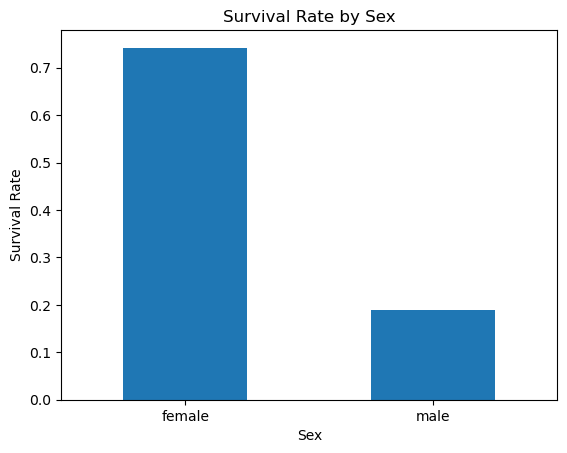

In [6]:
sex_survival = df.groupby('Sex')['Survived'].mean()
print(sex_survival)

sex_survival.plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

## Survival by Passenger Class

Passenger class likely affected access to lifeboats and location on the ship. I expect first-class passengers to have the highest survival rates and third-class passengers to have the lowest.

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


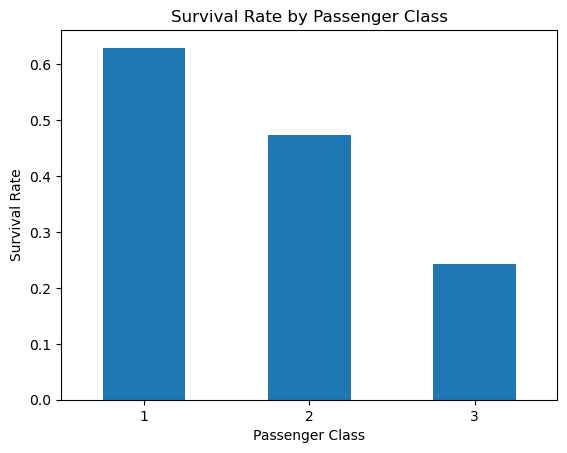

In [7]:
class_survival = df.groupby('Pclass')['Survived'].mean()
print(class_survival)

class_survival.plot(kind='bar')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.xticks(rotation=0)
plt.show()

## Survival by Age Group

Age may have influenced survival because children were often prioritized during evacuation. I grouped ages into Child, Teen, Adult, and Senior categories to compare survival patterns.

AgeGroup
Adult      0.386087
Child      0.573529
Senior     0.269231
Teen       0.488889
Unknown    0.293785
Name: Survived, dtype: float64


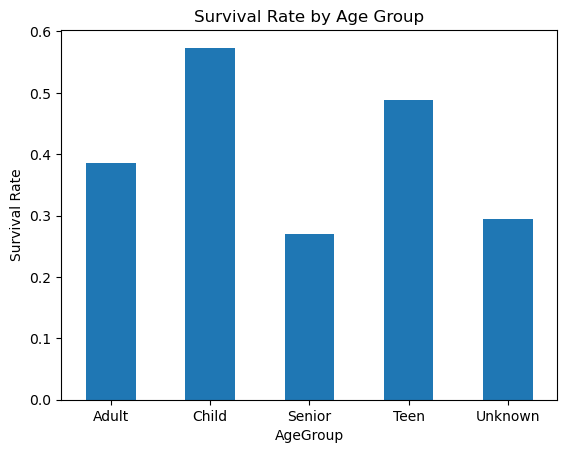

In [8]:
age_survival = df.groupby('AgeGroup')['Survived'].mean()
print(age_survival)

age_survival.plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

## Survival by Fare Group

Fare may reflect wealth and class status. Passengers with higher fares may have had better cabin locations and better access to lifeboats.

FareGroup
High      0.581081
Low       0.252273
Medium    0.445415
Name: Survived, dtype: float64


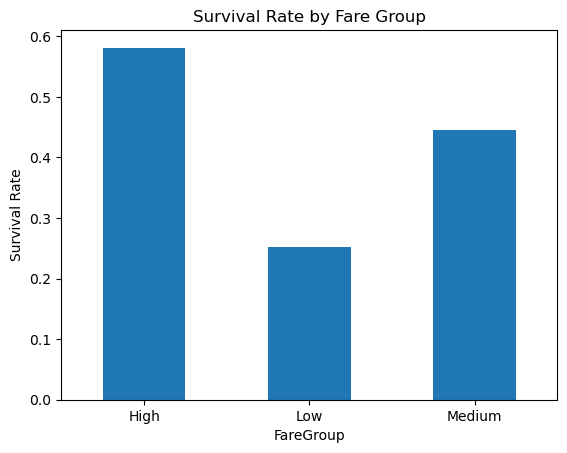

In [9]:
fare_survival = df.groupby('FareGroup')['Survived'].mean()
print(fare_survival)

fare_survival.plot(kind='bar')
plt.title('Survival Rate by Fare Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

## Survival by Travel Companions

Travel companions include:
- `SibSp`: siblings/spouse aboard
- `Parch`: parents/children aboard

I created a total family/travel companion count to see whether traveling alone or with others affected survival.

Companions
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


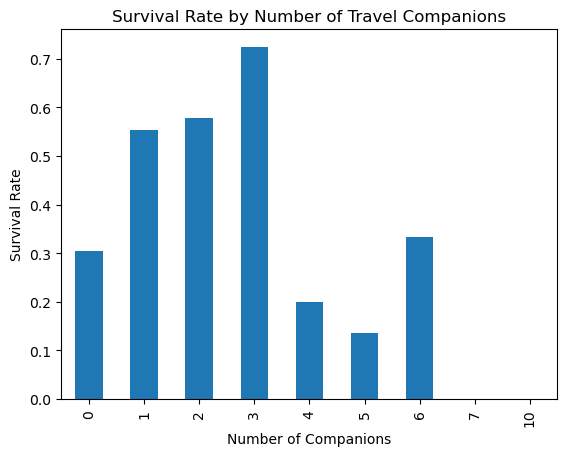

In [10]:
df['Companions'] = df['SibSp'] + df['Parch']

companion_survival = df.groupby('Companions')['Survived'].mean()
print(companion_survival)

companion_survival.plot(kind='bar')
plt.title('Survival Rate by Number of Travel Companions')
plt.ylabel('Survival Rate')
plt.xlabel('Number of Companions')
plt.show()

## Survival by Port of Departure

The `Embarked` column shows where each passenger boarded:
- C = Cherbourg
- Q = Queenstown
- S = Southampton

I compared survival rates by port of departure to see whether embarkation location was related to survival.

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


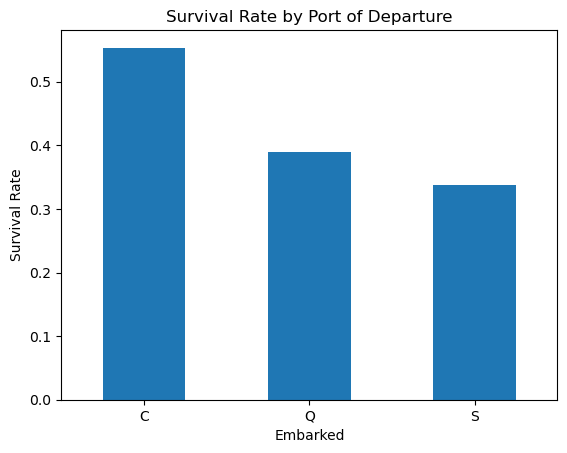

In [11]:
embarked_survival = df.groupby('Embarked')['Survived'].mean()
print(embarked_survival)

embarked_survival.plot(kind='bar')
plt.title('Survival Rate by Port of Departure')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

## Character Profile: Most Likely to Survive

Based on the visualizations and survival trends in the dataset, the character most likely to survive would have the following traits:

- **Sex:** Female
- **Passenger Class:** 1st class
- **Age Group:** Adult
- **Fare Group:** High
- **Travel Companions:** 0 to 2 companions
- **Port of Departure:** Cherbourg (C)

### Reasoning
Females had much higher survival rates than males. First-class passengers survived at higher rates than second- and third-class passengers. Passengers paying higher fares also had higher survival rates. Adults had strong survival outcomes, especially women in first class. Smaller travel groups may have been easier to evacuate, and passengers embarking from Cherbourg appear to have had a stronger survival rate than some other groups.

## Character Profile: Least Likely to Survive

Based on the visualizations and survival trends in the dataset, the character least likely to survive would have the following traits:

- **Sex:** Male
- **Passenger Class:** 3rd class
- **Age Group:** Adult
- **Fare Group:** Low
- **Travel Companions:** Larger group
- **Port of Departure:** Southampton (S)

### Reasoning
Males had much lower survival rates than females. Third-class passengers had the lowest survival rates overall. Lower fares were associated with lower survival rates, which likely overlaps with lower passenger class. Adult males in third class appear especially vulnerable in the dataset. Larger family groups may also have faced more difficulty escaping quickly.

## Real Passenger Match for Most Likely to Survive

The table below shows real passengers in the Titanic dataset who match the profile of the character most likely to survive.

In [12]:
most_likely_match = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['AgeGroup'] == 'Adult') &
    (df['FareGroup'] == 'High') &
    (df['Companions'] <= 2) &
    (df['Embarked'] == 'C')
]

most_likely_match[['Name', 'Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Embarked', 'Survived']].head(10)

,Name,Age,Fare,Pclass,SibSp,Parch,Embarked,Survived
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833,1,1,0,C,1
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",49.0,76.7292,1,1,0,C,1
195,"Lurette, Miss. Elise",58.0,146.5208,1,0,0,C,1
215,"Newell, Miss. Madeleine",31.0,113.2750,1,1,0,C,1
218,"Bazzani, Miss. Albina",32.0,76.2917,1,0,0,C,1
258,"Ward, Miss. Anna",35.0,512.3292,1,0,0,C,1
291,"Bishop, Mrs. Dickinson H (Helen Walton)",19.0,91.0792,1,1,0,C,1
299,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",50.0,247.5208,1,0,1,C,1
309,"Francatelli, Miss. Laura Mabel",30.0,56.9292,1,0,0,C,1
310,"Hays, Miss. Margaret Bechstein",24.0,83.1583,1,0,0,C,1


## Real Passenger Match for Least Likely to Survive

The table below shows real passengers in the Titanic dataset who match the profile of the character least likely to survive.

In [13]:
least_likely_match = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['AgeGroup'] == 'Adult') &
    (df['FareGroup'] == 'Low') &
    (df['Companions'] >= 1) &
    (df['Embarked'] == 'S')
]

least_likely_match[['Name', 'Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Embarked', 'Survived']].head(10)

,Name,Age,Fare,Pclass,SibSp,Parch,Embarked,Survived
0,"Braund, Mr. Owen Harris",22.0,7.2500,3,1,0,S,0
69,"Kink, Mr. Vincenz",26.0,8.6625,3,2,0,S,0
104,"Gustafsson, Mr. Anders Vilhelm",37.0,7.9250,3,2,0,S,0
175,"Klasen, Mr. Klas Albin",18.0,7.8542,3,1,1,S,0
197,"Olsen, Mr. Karl Siegwart Andreas",42.0,8.4042,3,0,1,S,0
267,"Persson, Mr. Ernst Ulrik",25.0,7.7750,3,1,0,S,1
371,"Wiklund, Mr. Jakob Alfred",18.0,6.4958,3,1,0,S,0
392,"Gustafsson, Mr. Johan Birger",28.0,7.9250,3,2,0,S,0
442,"Petterson, Mr. Johan Emil",25.0,7.7750,3,1,0,S,0
477,"Braund, Mr. Lewis Richard",29.0,7.0458,3,1,0,S,0


## External Research on Real Passengers

After identifying passengers in the dataset, I selected the following two individuals and researched them using Encyclopedia Titanica.

---

### Most Likely to Survive Passenger  
**Name:** Florence Briggs Cumings  

Florence Briggs Cumings was a first-class passenger traveling from Cherbourg. She survived the Titanic disaster, which aligns with the data showing that women in first class had some of the highest survival rates. She paid a high fare (over 71), which reflects her wealth and access to better accommodations on the ship. 

**Interesting Fact:**  
Florence was traveling with her husband, John Bradley Cumings, and she escaped the sinking while many lower-class passengers did not. Her survival highlights the strong advantage that first-class female passengers had during the evacuation.

---

### Least Likely to Survive Passenger  
**Name:** Owen Harris Braund  

Owen Harris Braund was a third-class passenger traveling from Southampton. He did not survive the sinking, which matches the data trends showing that adult males in third class had some of the lowest survival rates. He paid a very low fare (7.25), indicating limited access to resources and lifeboats. 

**Interesting Fact:**  
Owen Harris Braund was only 22 years old and was traveling with his wife. While he died in the disaster, his wife survived, which reflects the “women and children first” policy that heavily impacted survival outcomes.

---

### Summary

These two real passengers strongly support the character profiles created in this analysis. Florence Briggs Cumings represents the type of passenger most likely to survive, while Owen Harris Braund represents the type least likely to survive. Their outcomes clearly align with the patterns observed in the dataset.

In [14]:
print("Most likely to survive match:")
print(most_likely_match.iloc[0]['Name'])

print("\nLeast likely to survive match:")
print(least_likely_match.iloc[0]['Name'])

Most likely to survive match:
Cumings, Mrs. John Bradley (Florence Briggs Thayer)

Least likely to survive match:
Braund, Mr. Owen Harris


## Conclusion

This analysis showed that survival on the Titanic was strongly influenced by sex, passenger class, fare, and other travel characteristics. Based on the dataset, the passenger most likely to survive would be a first-class adult female paying a high fare, likely traveling with a small group and embarking from Cherbourg. The passenger least likely to survive would be a third-class adult male paying a low fare, likely traveling with companions and embarking from Southampton.

By comparing the fictional profiles to real passengers in the dataset, I was able to connect the data to historical individuals and make the profiles more realistic.